In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import json

from egci_bioacoustic_shifts import plot_EGCI
"""
region
    svm
    div
    data
        soundscape [complexity, entropy, empty]
        focal [complexity, entropy, empty]

"""
with open("e2_results.json", "r") as f:
    e2_results = json.load(f)
df = pd.DataFrame.from_dict(json.loads(e2_results["HSN"]["data"]["soundscape"]), orient='columns')
df

,Entropy,Complexity,Loss,GT,Predictions
0,0.885505,0.163722,0.693147,0.0,"[[-6.2254462242, -3.2270894051, -5.7316441536,..."
1,0.543981,0.237420,0.693147,0.0,"[[-6.6796030998, -3.4917674065, -6.1221065521,..."
2,0.710795,0.340318,0.693147,0.0,"[[-5.9402813911, -3.100158453, -5.4772377014, ..."
3,0.329516,0.231344,1.590072,1.0,"[[-31.1327400208, -18.215297699, -28.898801803..."
4,0.069286,0.066835,0.693147,0.0,"[[-11.1428642273, -9.0970058441, -9.9107656479..."
...,...,...,...,...,...
1992,0.394339,0.223263,2.296182,1.0,"[[-35.635433197, -21.228225708, -33.0436096191..."
1993,0.622161,0.232545,0.693147,0.0,"[[-6.5920562744, -3.4493010044, -6.035525322, ..."
1994,0.056413,0.053978,0.693147,0.0,"[[-40.9079856873, -24.995475769, -37.622081756..."
1995,0.175601,0.140846,2.265941,1.0,"[[-35.1016273499, -20.4192886353, -32.40855026..."


In [2]:
e2_results["HSN"]["data"]["soundscape"]

'{"Entropy":{"0":0.8855053762,"1":0.5439811122,"2":0.710795127,"3":0.3295157464,"4":0.069285531,"5":0.0893080878,"6":0.1083013089,"7":0.0738820818,"8":0.675993816,"9":0.090733904,"10":0.1562157724,"11":0.7166826865,"12":0.2723046955,"13":0.1028645638,"14":0.521047031,"15":0.0939622207,"16":0.7428445469,"17":0.730320601,"18":0.4229728261,"19":0.6735361951,"20":0.8571473499,"21":0.1244575699,"22":0.0538919403,"23":0.39778754,"24":0.6511090733,"25":0.4663594261,"26":0.6025241821,"27":0.7382269056,"28":0.1677981815,"29":0.7282803385,"30":0.8754288596,"31":0.864965992,"32":0.7564829788,"33":0.0918217682,"34":0.8561055417,"35":0.7435283284,"36":0.1622953739,"37":0.5770019053,"38":0.5801634281,"39":0.5812599346,"40":0.5186397061,"41":0.66286957,"42":0.4426021945,"43":0.6765188113,"44":0.3960100117,"45":0.6438974824,"46":0.5964818987,"47":0.1443308814,"48":0.8746176341,"49":0.519819458,"50":0.7102016082,"51":0.6833509622,"52":0.2095126834,"53":0.6482782312,"54":0.0784577822,"55":0.0855892459,"

In [3]:
import statsmodels.api as sm
experiment_results = {}
region = "HSN"
df = pd.DataFrame(json.loads(e2_results[region]["data"]["soundscape"]))
X = sm.add_constant(df[['Entropy', 'Complexity', 'GT']])
model = sm.OLS(df['Loss'], X).fit()

experiment_results[region] = {}
experiment_results[region]["results"] = str(model.summary())
print(experiment_results[region])
experiment_results[region]["data"]  = {
    "soundscape": df.to_json()
}

{'results': '                            OLS Regression Results                            \n==============================================================================\nDep. Variable:                   Loss   R-squared:                       0.568\nModel:                            OLS   Adj. R-squared:                  0.567\nMethod:                 Least Squares   F-statistic:                     873.7\nDate:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00\nTime:                        13:14:44   Log-Likelihood:                -517.56\nNo. Observations:                1997   AIC:                             1043.\nDf Residuals:                    1993   BIC:                             1066.\nDf Model:                           3                                         \nCovariance Type:            nonrobust                                         \n==============================================================================\n                 coef    st

In [4]:
Huber_model = sm.RLM(df['Loss'], X, M=sm.robust.norms.HuberT()).fit()
Huber_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                   Loss   No. Observations:                 1997
Model:                            RLM   Df Residuals:                     1993
Method:                          IRLS   Df Model:                            3
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 05 Dec 2025                                         
Time:                        13:14:44                                         
No. Iterations:                    50                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6933   1.33e-05    5.2e+04      0.000       0.693       0.693
Entropy       -0.0002   2.55e-05     -7.081      0.000      -0.000      -0.000
Complexity    -0.0002   7.88e-05     -2.022      0.043      -0.000    -4.9e-06
GT             0.3977    7.3e-06   5.45e+04      0.000       0.398       0.398
==============================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [5]:
with open("e2_results.json", "r") as f:
    e2_results = json.load(f)
df = pd.DataFrame.from_dict(json.loads(e2_results["PER"]["data"]["soundscape"]), orient='columns')
Huber_model = sm.RLM(df['Loss'], X, M=sm.robust.norms.HuberT()).fit()
Huber_model.summary()

ValueError: The indices for endog and exog are not aligned

# =================================================

In [ ]:
df['loss']

0       [0.6931471824645996, 1.0082141160964966, 0.523...
1       [0.6931471824645996, 1.0082141160964966, 0.523...
2       [0.6931471824645996, 1.0082141160964966, 0.523...
3       [0.6931471824645996, 1.0082141160964966, 0.523...
4       [0.6931471824645996, 1.0082141160964966, 0.523...
                              ...                        
1995    [0.6931471824645996, 1.0082141160964966, 0.523...
1996    [0.6931471824645996, 1.0082141160964966, 0.523...
1997    [0.6931471824645996, 1.0082141160964966, 0.523...
1998    [0.6931471824645996, 1.0082141160964966, 0.523...
1999    [0.6931471824645996, 1.0082141160964966, 0.523...
Name: loss, Length: 2000, dtype: object

In [ ]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split
with open("e2_results_2.json", "r") as f:
    e2_results = json.load(f)

df = pd.DataFrame(e2_results["HSN"]["data"]["raw_data"])
df = df[~df.isnull().any(axis=1)]
df["GT"] = df["gt"].apply(len)
train_valid, test = train_test_split(df, test_size=0.2)
train, valid = train_test_split(train_valid, test_size=0.2)
train.shape

import statsmodels.api as sm

X = sm.add_constant(train[['entropy', 'complexity', 'GT']])
ols_model = sm.OLS(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
ols_model.summary()

/home/s.perry.543/egci_bioacoustic_shifts/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['M']
  warnings.warn(msg, ValueWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   loss   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     498.1
Date:                Mon, 01 Dec 2025   Prob (F-statistic):          4.74e-214
Time:                        11:54:03   Log-Likelihood:                -449.48
No. Observations:                1277   AIC:                             907.0
Df Residuals:                    1273   BIC:                             927.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8817      0.028     31.802      0.000       0.827       0.936
entropy       -0.2582      0.052     -4.924      0.000      -0.361      -0.155
complexity    -0.3148      0.161     -1.958      0.050      -0.630       0.001
GT             0.5586      0.015     37.842      0.000       0.530       0.588
==============================================================================
Omnibus:                      949.566   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            23802.705
Skew:                           3.182   Prob(JB):                         0.00
Kurtosis:                      23.171   Cond. No.                         22.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
X = sm.add_constant(train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity', 'acoustic_richness', 'bioacoustic_index', 'GT']])
Huber_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
Huber_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                   loss   No. Observations:                 1277
Model:                            RLM   Df Residuals:                     1270
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Mon, 01 Dec 2025                                         
Time:                        11:52:43                                         
No. Iterations:                    50                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
entropy                -0.0119      0.003     -4.425      0.000      -0.017      -0.007
complexity             -0.0220      0.008     -2.611      0.009      -0.039      -0.005
acoustic_complexity    -0.0006    4.9e-05    -13.065      0.000      -0.001      -0.001
acoustic_diversity      0.0022      0.001      2.042      0.041     8.7e-05       0.004
acoustic_richness       0.8863      0.014     61.184      0.000       0.858       0.915
bioacoustic_index    2.746e-06   2.68e-06      1.024      0.306   -2.51e-06       8e-06
GT                      0.3703      0.001    507.135      0.000       0.369       0.372
=======================================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [ ]:
train["loss"].value_counts()

loss
0.693147    670
0.744686      3
1.440203      2
1.024237      2
1.627771      2
           ... 
1.515632      1
1.283951      1
1.245303      1
1.277974      1
2.690783      1
Name: count, Length: 578, dtype: int64

In [ ]:
train[(train["GT"] == 0) & (train["loss"] < 0.7)   ] 

,path,offset_s,sr,gt,entropy,complexity,lag,acoustic_complexity,acoustic_diversity,acoustic_richness,bioacoustic_index,loss,GT
790,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.787960,0.199173,256,299.043371,2.302491,1.0,837.085412,0.693147,0
40,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.085589,0.079847,256,295.959790,0.612774,1.0,992.087359,0.693147,0
1299,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.478132,0.300717,256,292.665730,2.273509,1.0,604.052896,0.693147,0
1027,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.758667,0.234649,256,292.845328,2.302544,1.0,555.213269,0.693147,0
503,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.090743,0.082185,256,293.913252,2.078777,1.0,986.216207,0.693147,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1717,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.670669,0.343259,256,315.332799,1.661513,1.0,827.493060,0.693147,0
1368,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.735364,0.351081,256,296.196491,2.302482,1.0,506.400135,0.693147,0
1695,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.735743,0.271094,256,297.259150,2.302497,1.0,886.831882,0.693147,0
1163,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.725467,0.244272,256,296.717043,2.302423,1.0,984.315992,0.693147,0


In [ ]:
X = sm.add_constant(train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity', 'acoustic_richness', 'bioacoustic_index', 'GT']])
ols_model = sm.OLS(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
ols_model.summary()

/home/s.perry.543/egci_bioacoustic_shifts/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['M']
  warnings.warn(msg, ValueWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   loss   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     258.5
Date:                Mon, 01 Dec 2025   Prob (F-statistic):          5.02e-216
Time:                        11:54:38   Log-Likelihood:                -435.71
No. Observations:                1277   AIC:                             885.4
Df Residuals:                    1270   BIC:                             921.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
entropy                -0.2892      0.057     -5.075      0.000      -0.401      -0.177
complexity             -0.4175      0.174     -2.398      0.017      -0.759      -0.076
acoustic_complexity    -0.0042      0.001     -4.327      0.000      -0.006      -0.002
acoustic_diversity      0.0526      0.022      2.428      0.015       0.010       0.095
acoustic_richness       2.0265      0.288      7.043      0.000       1.462       2.591
bioacoustic_index    4.416e-05   5.48e-05      0.805      0.421   -6.34e-05       0.000
GT                      0.5691      0.015     38.398      0.000       0.540       0.598
==============================================================================
Omnibus:                      942.303   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            23209.077
Skew:                           3.152   Prob(JB):                         0.00
Kurtosis:                      22.911   Cond. No.                     2.54e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.54e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

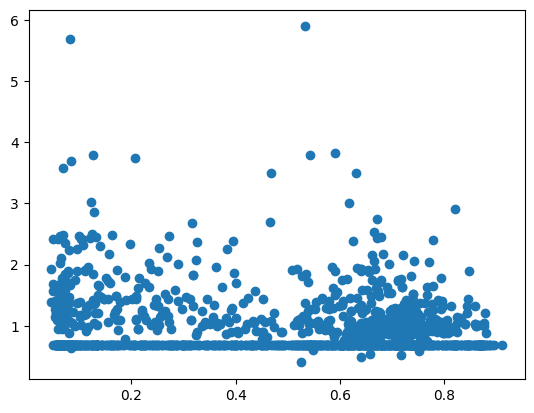

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(train["entropy"], train["loss"])

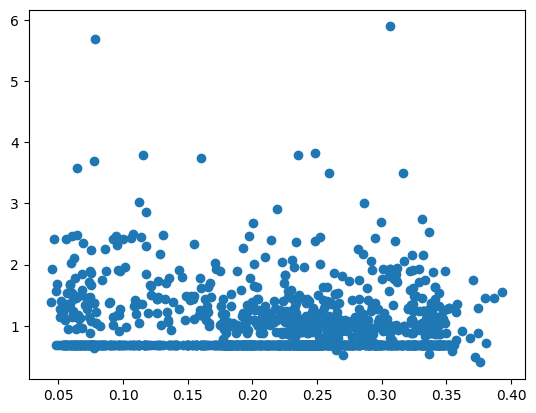

In [ ]:
plt.scatter(train["complexity"], train["loss"])

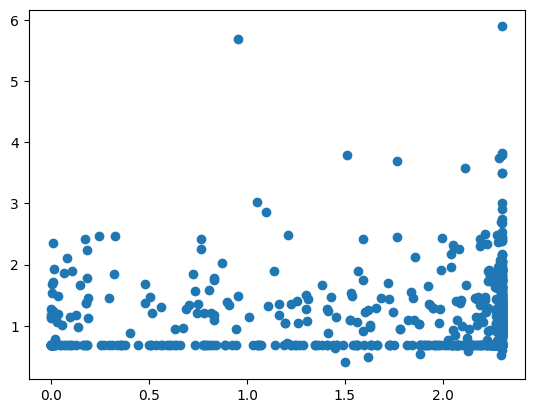

In [ ]:
plt.scatter(train["acoustic_diversity"], train["loss"])

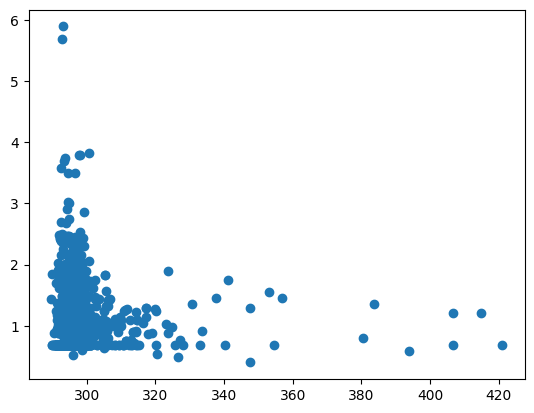

In [ ]:
plt.scatter(train["acoustic_complexity"], train["loss"])

In [ ]:
plt.scatter(train["acoustic_richness"], train["loss"])

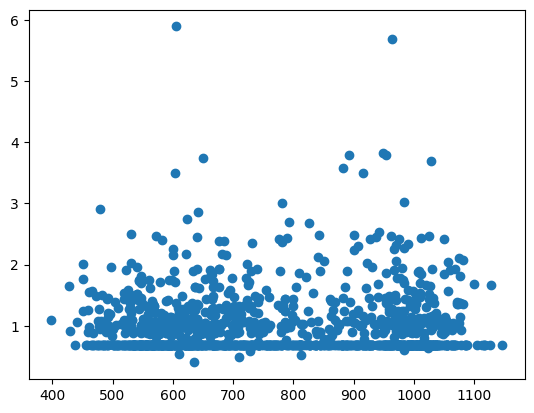

In [ ]:
plt.scatter(train["bioacoustic_index"], train["loss"])

In [ ]:
train_only_birds = train[train["GT"] > 0]

X = sm.add_constant(train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']]) #'acoustic_richness', Seems to always be 1. That isn't useful
Huber_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
Huber_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                   loss   No. Observations:                 1277
Model:                            RLM   Df Residuals:                     1270
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Mon, 01 Dec 2025                                         
Time:                        12:09:18                                         
No. Iterations:                    50                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.9053      0.035     25.789      0.000       0.837       0.974
entropy                -0.0357      0.007     -5.141      0.000      -0.049      -0.022
complexity             -0.0560      0.021     -2.636      0.008      -0.098      -0.014
acoustic_complexity    -0.0006      0.000     -5.421      0.000      -0.001      -0.000
acoustic_diversity      0.0045      0.003      1.708      0.088      -0.001       0.010
bioacoustic_index   -1.362e-06   6.69e-06     -0.204      0.839   -1.45e-05    1.18e-05
GT                      0.3852      0.002    213.029      0.000       0.382       0.389
=======================================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

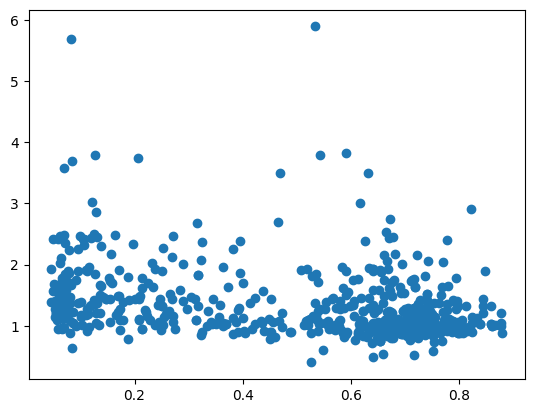

In [ ]:
plt.scatter(train_only_birds["entropy"], train_only_birds["loss"])